This notebook trains **Support Vector Regression (SVR)** models to predict taxi-trip demand in spatio-temporal resolution (spatial unit × time basket) using the prepared datasets in `Data/03`.

Three temporal resolutions are available (**1 h, 4 h, 1 d**) and two spatial layers (**census tract, community area**), each pre-split into **train / validation / test**.

### Approach (sequential model selection)
Rather than exhaustively testing every combination, the analysis proceeds in three selection phases so that each decision builds on the previous one:

| Phase | Question | Configurations |
|---|---|---|
| **1 — Spatial layer** (1 h) | census tract vs community area | both *normal* target, weather features |
| **2 — Target transform** (1 h) | normal vs `log1p` | best spatial layer from Phase 1 |
| **3 — Temporal resolution** | 1 h vs 4 h vs 1 d | best spatial + best target from Phase 2 |

The model family (LinearSVR → RBF → Polynomial) and all hyperparameters are selected with **grid search on the validation set** (see *Validation strategy*). Final performance is always reported on the held-out **test set**.

## 0) Setup and configuration


In [2]:
# imports
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import LinearSVR, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = "../Data/03"

# colours for plots (matplotlib named colours)
SPATIAL_COLORS = {"census_tract": "steelblue", "community_area": "seagreen"}
BIN_COLORS = {"1h": "steelblue", "4h": "darkorange", "1d": "mediumpurple"}


# 1) Data loading
Each dataset comes as three pre-split parquet files (**train / val / test**). The splits were created chronologically in notebook *03* (most recent period = test, the period before = validation). All six dataset configurations (2 spatial × 3 temporal) share the same 32 columns.


In [3]:
# census_tract
ct_1h_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_train.parquet")
ct_1h_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_val.parquet")
ct_1h_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1h_test.parquet")
ct_4h_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_train.parquet")
ct_4h_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_val.parquet")
ct_4h_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_4h_test.parquet")
ct_1d_train = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_train.parquet")
ct_1d_val   = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_val.parquet")
ct_1d_test  = pl.read_parquet(f"{DATA_DIR}/03_census_tract_1d_test.parquet")
# community_area
ca_1h_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_train.parquet")
ca_1h_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_val.parquet")
ca_1h_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_1h_test.parquet")
ca_4h_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_train.parquet")
ca_4h_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_val.parquet")
ca_4h_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_4h_test.parquet")
ca_1d_train = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_train.parquet")
ca_1d_val   = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_val.parquet")
ca_1d_test  = pl.read_parquet(f"{DATA_DIR}/03_community_area_1d_test.parquet")

# quick overview of the two 1h datasets
for name, tr in [("census_tract_1h", ct_1h_train), ("community_area_1h", ca_1h_train)]:
    print(f"{name}: train={tr.shape[0]:,}  trip_count mean={tr['trip_count'].mean():.1f}")


census_tract_1h: train=271,145  trip_count mean=15.9
community_area_1h: train=617,263  trip_count mean=14.7


## 1.1) Target distribution
`trip_count` is right-skewed with a long tail — typical for demand data. Most spatial-unit/time baskets have low counts while a few have very high demand. This skew motivates the `log1p` target transform tested in Phase 2.


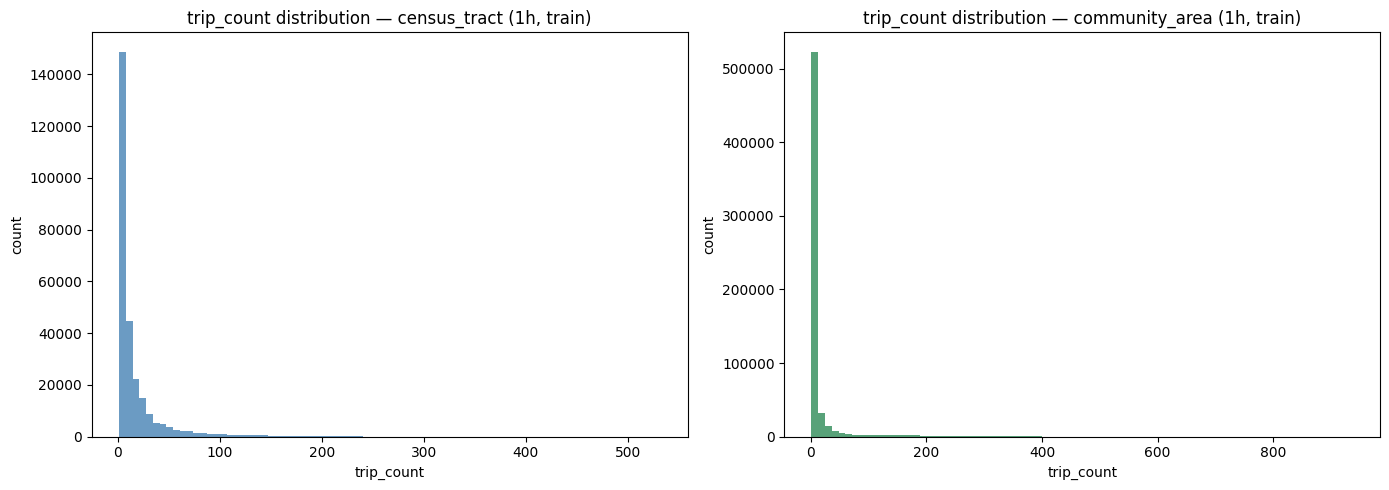

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (spatial, tr) in zip(axes, [("census_tract", ct_1h_train), ("community_area", ca_1h_train)]):
    ax.hist(tr["trip_count"].to_numpy(), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    ax.set_title(f"trip_count distribution — {spatial} (1h, train)")
    ax.set_xlabel("trip_count"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()


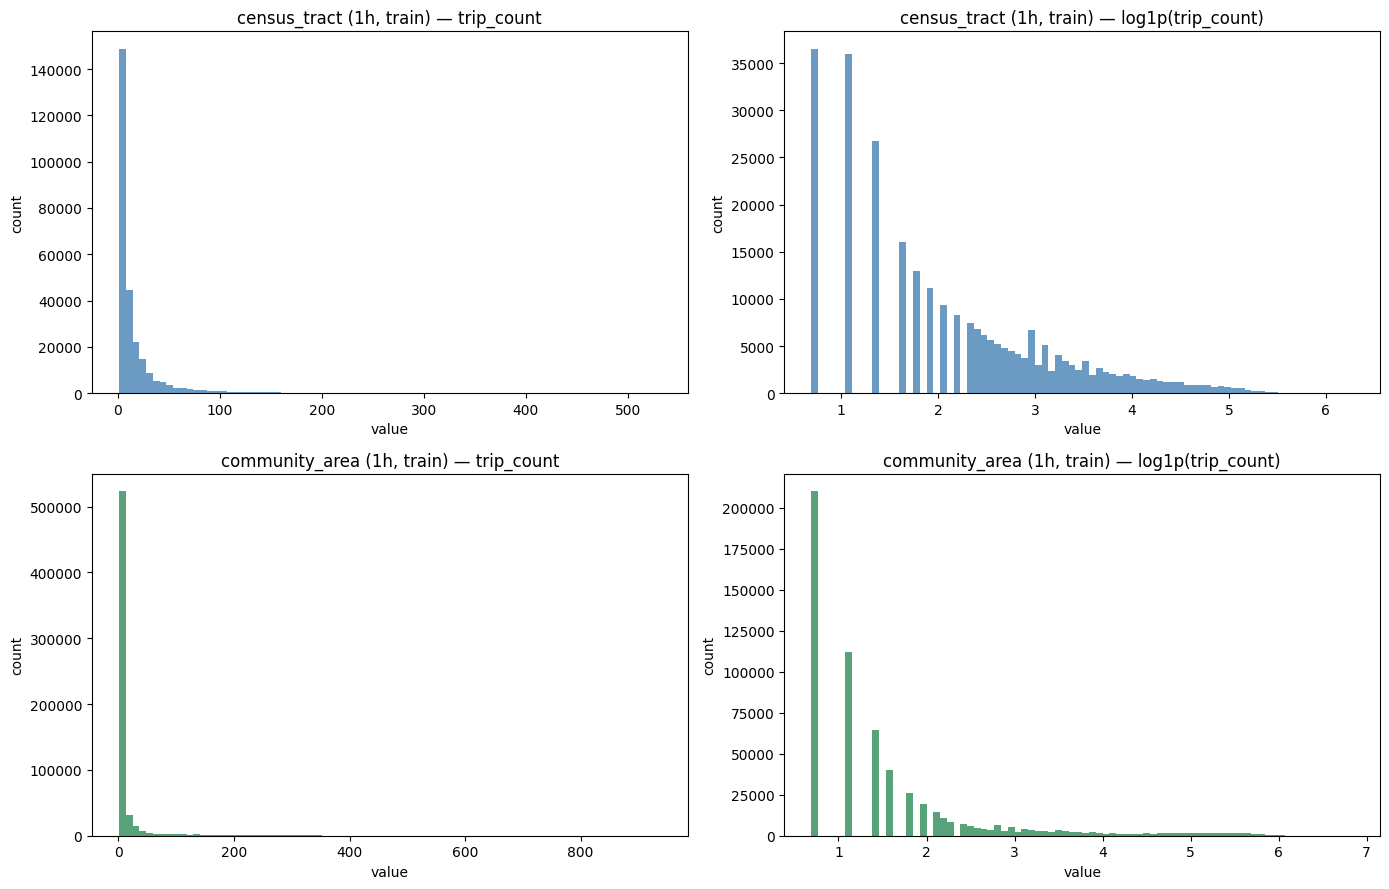

In [5]:
# right-skewed target -> motivates the log1p transform tested in Phase 2
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (spatial, tr) in enumerate([("census_tract", ct_1h_train),
                                     ("community_area", ca_1h_train)]):
    vals = tr["trip_count"].to_numpy()
    axes[row, 0].hist(vals, bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 0].set_title(f"{spatial} (1h, train) — trip_count")
    axes[row, 1].hist(np.log1p(vals), bins=80, color=SPATIAL_COLORS[spatial], alpha=0.8)
    axes[row, 1].set_title(f"{spatial} (1h, train) — log1p(trip_count)")
    for ax in axes[row]:
        ax.set_xlabel("value"); ax.set_ylabel("count")
plt.tight_layout(); plt.show()

# 2) Feature preparation
The feature set is fixed and known (the data from notebook 03 has a stable schema), so it is listed explicitly rather than auto-detected. The only addition is a **target encoding**: the mean `trip_count` per spatial unit, computed on the training set only and joined to train / val / test. Unseen spatial units in val/test fall back to the global training mean — no leakage.

For **daily bins** the `hour_sin` / `hour_cos` features are excluded (an hour-of-day signal is meaningless when every basket spans a full day).


In [6]:
# explicit feature columns (everything except the spatial ID and the target trip_count)
FEATURE_COLS = [
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "DayOfWeek_Friday", "DayOfWeek_Saturday", "DayOfWeek_Sunday",
    "DayOfWeek_Thursday", "DayOfWeek_Tuesday", "DayOfWeek_Wednesday",
    "BankHoliday", "CorporateHoliday", "CityHoliday", "StateHoliday",
    "rain", "strong_rain", "snow", "wind", "strong_wind",
    "temperature_c", "temperature_max_c", "temperature_min_c",
    "healthcare", "education", "amenity", "leisure",
    "shops", "public_services", "tourism", "nature",
]
# daily bins have no hour-of-day signal -> drop hour_sin / hour_cos
FEATURE_COLS_1D = [c for c in FEATURE_COLS if c not in ("hour_sin", "hour_cos")]


def prepare_dataset(train_df, val_df, test_df, spatial_col, bin_label="1h", target_encoding=True):
    """Target encoding (train only) + numpy arrays. Targets stay in the original scale."""
    feats = FEATURE_COLS_1D if bin_label == "1d" else FEATURE_COLS

    if target_encoding:
        # target encoding: mean trip_count per spatial unit (train only)
        spatial_mean = (train_df.group_by(spatial_col)
                        .agg(pl.col("trip_count").mean().alias("spatial_target_mean")))
        global_mean = train_df["trip_count"].mean()
        train_df = train_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        val_df = val_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        test_df = test_df.join(spatial_mean, on=spatial_col, how="left").with_columns(
            pl.col("spatial_target_mean").fill_null(global_mean))
        feat_final = feats + ["spatial_target_mean"]
    else:
        feat_final = feats

    return {
        "X_train": train_df.select(feat_final).to_numpy(),
        "y_train": train_df["trip_count"].to_numpy().astype(float),
        "X_val":   val_df.select(feat_final).to_numpy(),
        "y_val":   val_df["trip_count"].to_numpy().astype(float),
        "X_test":  test_df.select(feat_final).to_numpy(),
        "y_test":  test_df["trip_count"].to_numpy().astype(float),
        "n_features": len(feat_final),
        "n_spatial": train_df[spatial_col].n_unique(),
    }


## Validation strategy
The datasets come **pre-split chronologically** into three parts:

| Split | Role |
|---|---|
| **Train** | fit the model |
| **Validation** | hyper-parameter / model-family selection (grid search) |
| **Test** | final, unbiased performance report |

A chronological split is essential: a random split would mix past and future rows and turn the task into temporal *interpolation* (neighbouring rows share the same weather/day-of-week constellation, letting the model “cheat”). Ordering by time guarantees the model is always evaluated on a **later** period than it was trained on.

Hyper-parameter tuning uses a **`PredefinedSplit`** built from the train + validation rows: every grid-search candidate is fit on the train fold and scored on the validation fold. Because kernel SVR scales ~O(n²) for fitting and O(n·n_sv) for prediction, grid search fits on a 20 k-row train subsample and scores on a 20 k-row validation subsample — both large enough for a stable hyper-parameter ranking. The best configuration is then refit on a 50 k-row train subsample and evaluated on the **full** test set.

> <b>[NOTE]</b> When `log1p` is used, both `y_train` and `y_val` are transformed so that grid-search scoring stays in a consistent (log) scale; predictions are mapped back with `expm1` and all reported metrics are computed against the original-scale test target.


# 3) Model training
Three SVR variants are trained, following the assignment's *“start without a kernel, then make it more complex”* instruction: **LinearSVR** (no kernel) → **RBF** → **Polynomial**. Each is tuned with grid search on the validation set; the best family is selected by validation RMSE, refit, and scored on the test set.

The `log1p` target transform (transform + inverse) is handled entirely inside `run_svr_pipeline` so both sides stay in one place.


In [7]:
GRID_SAMPLE_SIZE = 20_000      # train subsample for grid-search fitting
VAL_SAMPLE_SIZE  = 20_000      # validation subsample for grid-search scoring
REFIT_SAMPLE_SIZE = 50_000     # train subsample for final refit


def _subsample(X, y, n, rng):
    # daily bins have fewer rows than the sample sizes -> return them unchanged
    if len(X) <= n:
        return X, y
    idx = rng.choice(len(X), size=n, replace=False)
    return X[idx], y[idx]


def run_svr_pipeline(data, log_target=False, tag=""):
    X_train, y_train = data["X_train"], data["y_train"]
    X_val,   y_val   = data["X_val"],   data["y_val"]
    X_test,  y_test  = data["X_test"],  data["y_test"]

    # log1p target transform (transform + inverse kept together in this function)
    if log_target:
        y_train = np.log1p(y_train)
        y_val   = np.log1p(y_val)

    # subsample train (fit) and validation (score) — kernel SVR is O(n^2)
    rng = np.random.default_rng(7)
    X_sub, y_sub = _subsample(X_train, y_train, GRID_SAMPLE_SIZE, rng)
    X_val_s, y_val_s = _subsample(X_val, y_val, VAL_SAMPLE_SIZE, rng)
    print(f"  [{tag}] fit on {len(X_sub):,} train rows, score on {len(X_val_s):,} val rows")

    # PredefinedSplit: -1 = train fold (fit here), 0 = validation fold (scored)
    ps = PredefinedSplit(np.concatenate([np.full(len(X_sub), -1), np.zeros(len(X_val_s))]))

    configs = [
        ("LinearSVR",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", LinearSVR(dual="auto", max_iter=10000, random_state=7))]),
         {"svr__C": [0.01, 0.1, 1, 10], "svr__epsilon": [0.1, 1, 10]}),
        ("RBF",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", SVR(kernel="rbf", max_iter=50_000, cache_size=2000))]),
         {"svr__C": [0.1, 1, 10],
          "svr__gamma": ["scale", 0.01, 0.1, 1],
          "svr__epsilon": [0.1, 1, 10]}),
        ("Poly",
         Pipeline([("scaler", StandardScaler()),
                   ("svr", SVR(kernel="poly", max_iter=50_000, cache_size=2000))]),
         {"svr__C": [0.1, 1, 10],
          "svr__degree": [2, 3],
          "svr__coef0": [0, 1],
          "svr__epsilon": [0.1, 1, 10]}),
    ]

    results = {}
    for model_name, pipe, grid in configs:
        gs = GridSearchCV(pipe, grid, cv=ps, scoring="neg_mean_squared_error",
                          n_jobs=-1, refit=False)
        gs.fit(np.vstack([X_sub, X_val_s]), np.concatenate([y_sub, y_val_s]))
        val_rmse = np.sqrt(-gs.best_score_)
        results[model_name] = {"val_rmse": val_rmse, "params": gs.best_params_, "pipe": pipe}
        print(f"    {model_name:10s} val RMSE={val_rmse:.4f}  {gs.best_params_}")

    # best model family by validation RMSE
    best_name = min(results, key=lambda k: results[k]["val_rmse"])
    best = results[best_name]
    model = best["pipe"].set_params(**best["params"])

    # refit on a larger train subsample
    X_refit, y_refit = _subsample(X_train, y_train, REFIT_SAMPLE_SIZE, rng)
    model.fit(X_refit, y_refit)

    print(f"    solver iterations used: {model.named_steps['svr'].n_iter_}")

    # predict on test (inverse-transform if log1p) -> metrics on original scale
    y_pred = model.predict(X_test)
    if log_target:
        y_pred = np.expm1(y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mask = y_test > 0
    mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    print(f"    -> best: {best_name} | test R2={r2:.4f} RMSE={rmse:.4f} MAE={mae:.4f} MAPE={mape:.2f}%")

    return {"best_model": best_name, "best_params": results[best_name]["params"],
            "val_rmse": results[best_name]["val_rmse"],
            "test_mae": mae, "test_rmse": rmse, "test_r2": r2, "test_mape": mape,
            "y_pred": y_pred, "y_test": y_test,
            "all_val_rmse": {k: v["val_rmse"] for k, v in results.items()}}


# 4) Phase 1 — Spatial layer comparison (1 h)
Both spatial layers are compared at **1 h** with a normal target and weather features. The better layer (by test R²) is carried forward to Phase 2.


In [8]:
phase1 = {}
p = prepare_dataset(ct_1h_train, ct_1h_val, ct_1h_test, "census_tract", "1h")
phase1["census_tract"] = run_svr_pipeline(p, tag="census_tract_1h")
phase1["census_tract"].update({"spatial": "census_tract", "bin": "1h",
                               "log_target": False, "tag": "census_tract_1h",
                               "n_features": p["n_features"]})

p = prepare_dataset(ca_1h_train, ca_1h_val, ca_1h_test, "community_area", "1h")
phase1["community_area"] = run_svr_pipeline(p, tag="community_area_1h")
phase1["community_area"].update({"spatial": "community_area", "bin": "1h",
                                 "log_target": False, "tag": "community_area_1h",
                                 "n_features": p["n_features"]})

BEST_SPATIAL = max(phase1, key=lambda k: phase1[k]["test_r2"])
print(f"\n>> Best spatial layer (1h): {BEST_SPATIAL} (R2={phase1[BEST_SPATIAL]['test_r2']:.4f})")


  [census_tract_1h] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=18.9011  {'svr__C': 10, 'svr__epsilon': 10}
    RBF        val RMSE=15.0617  {'svr__C': 10, 'svr__epsilon': 10, 'svr__gamma': 'scale'}


c:\Users\Kusha\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    Poly       val RMSE=14.4645  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 10}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.6942 RMSE=12.5676 MAE=7.1206 MAPE=122.38%
  [community_area_1h] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=33.4912  {'svr__C': 10, 'svr__epsilon': 10}


c:\Users\Kusha\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    RBF        val RMSE=25.3649  {'svr__C': 10, 'svr__epsilon': 10, 'svr__gamma': 'scale'}
    Poly       val RMSE=20.1577  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 10}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.8278 RMSE=19.7086 MAE=7.9764 MAPE=207.27%

>> Best spatial layer (1h): community_area (R2=0.8278)


# 4.1) Ablation — is target encoding necessary?
The target-encoding feature (`spatial_target_mean`) gives the model the historical average demand per area. To check whether this actually helps — or whether the POI / weather / time features alone are enough — the winning 1 h configuration is run once **without** target encoding and compared against the Phase 1 result (which has it).


In [9]:
# winning spatial layer's 1h data
if BEST_SPATIAL == "census_tract":
    tr, va, te = ct_1h_train, ct_1h_val, ct_1h_test
else:
    tr, va, te = ca_1h_train, ca_1h_val, ca_1h_test

data_no_te = prepare_dataset(tr, va, te, BEST_SPATIAL, "1h", target_encoding=False)
res_no_te = run_svr_pipeline(data_no_te, tag=f"{BEST_SPATIAL}_1h (no target encoding)")

r2_with = phase1[BEST_SPATIAL]["test_r2"]
r2_without = res_no_te["test_r2"]
print(f"\n>> Target encoding: with R2={r2_with:.4f}  vs  without R2={r2_without:.4f}  "
      f"({'keep' if r2_with >= r2_without else 'drop'})")


  [community_area_1h (no target encoding)] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=40.3633  {'svr__C': 10, 'svr__epsilon': 10}


c:\Users\Kusha\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


    RBF        val RMSE=28.8787  {'svr__C': 10, 'svr__epsilon': 10, 'svr__gamma': 'scale'}
    Poly       val RMSE=22.6736  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 10}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=0.8175 RMSE=20.2871 MAE=8.7247 MAPE=247.03%

>> Target encoding: with R2=0.8278  vs  without R2=0.8175  (keep)


# 5) Phase 2 — Target transform comparison (1 h)
Using the best spatial layer from Phase 1, a **normal** vs **`log1p`** target is compared at 1 h. The `log1p` transform compresses the right-skewed demand distribution; predictions are mapped back with `expm1` and all metrics are computed against the original-scale test target.

> The *normal*-target result is reused from Phase 1 (same configuration), so only one new model is trained here.


In [10]:
phase2 = {"normal": phase1[BEST_SPATIAL]}
# pick the matching 1h train/val/test for the winning spatial layer
if BEST_SPATIAL == "census_tract":
    tr, va, te = ct_1h_train, ct_1h_val, ct_1h_test
else:
    tr, va, te = ca_1h_train, ca_1h_val, ca_1h_test
tag = f"{BEST_SPATIAL}_1h + log1p"
p = prepare_dataset(tr, va, te, BEST_SPATIAL, "1h")
phase2["log1p"] = run_svr_pipeline(p, log_target=True, tag=tag)
phase2["log1p"].update({"spatial": BEST_SPATIAL, "bin": "1h",
                        "log_target": True, "tag": tag,
                        "n_features": p["n_features"]})

if phase2["log1p"]["test_r2"] > phase2["normal"]["test_r2"]:
    BEST_TARGET = "log1p"
else:
    BEST_TARGET = "normal"
print(f"\n>> Best target setting (1h): {BEST_TARGET} (R2={phase2[BEST_TARGET]['test_r2']:.4f})")


  [community_area_1h + log1p] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=0.6644  {'svr__C': 0.01, 'svr__epsilon': 0.1}
    RBF        val RMSE=0.4511  {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}
    Poly       val RMSE=0.4579  {'svr__C': 1, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: RBF | test R2=0.8451 RMSE=18.6933 MAE=5.7150 MAPE=49.39%

>> Best target setting (1h): log1p (R2=0.8451)


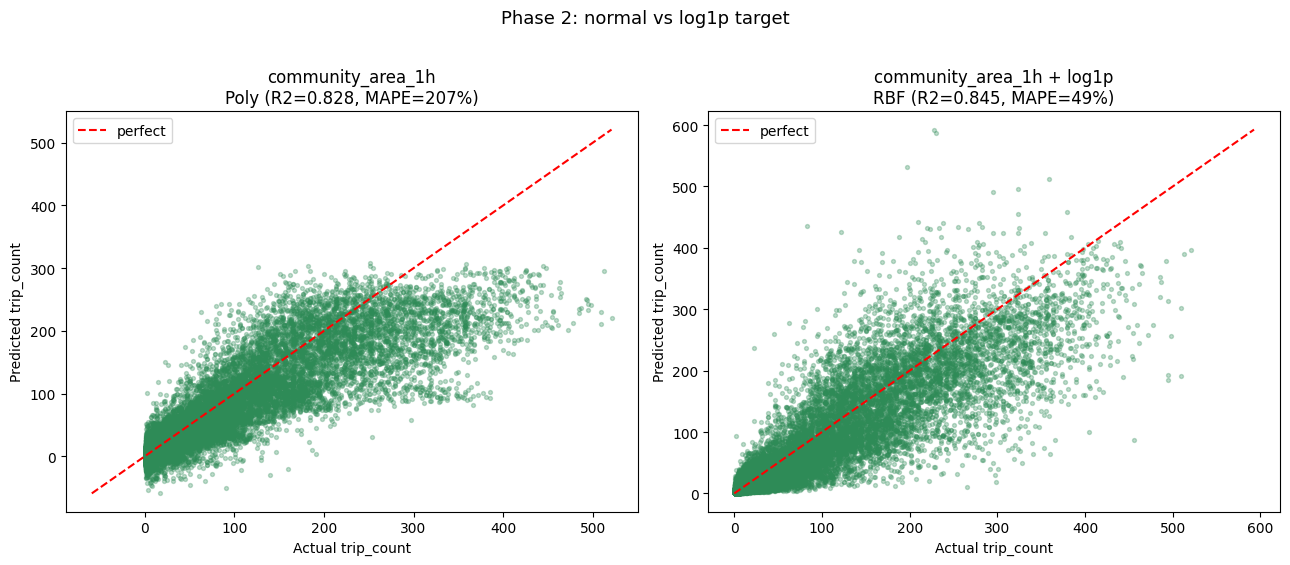

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, key in zip(axes, ["normal", "log1p"]):
    res = phase2[key]
    yt, yp = res["y_test"], res["y_pred"]
    ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
    ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
    ax.set_title(f"{res['tag']}\n{res['best_model']} "
                 f"(R2={res['test_r2']:.3f}, MAPE={res['test_mape']:.0f}%)")
    ax.legend()
fig.suptitle("Phase 2: normal vs log1p target", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

# 6) Phase 3 — Temporal resolution comparison
With the best spatial layer and best target setting fixed, the three temporal resolutions (**1 h, 4 h, 1 d**) are compared. The 1 h result is reused from Phase 2; the 4 h and 1 d models are trained here.

Coarser temporal bins aggregate more trips per basket, so absolute demand (and RMSE) increase — the relevant comparison is **R²** (relative fit quality) and **MAPE** (relative error).


In [12]:
phase3 = {"1h": phase2[BEST_TARGET]}
# train/val/test lookup for the winning spatial layer, all temporal bins
if BEST_SPATIAL == "census_tract":
    bin_data = {"4h": (ct_4h_train, ct_4h_val, ct_4h_test),
                "1d": (ct_1d_train, ct_1d_val, ct_1d_test)}
else:
    bin_data = {"4h": (ca_4h_train, ca_4h_val, ca_4h_test),
                "1d": (ca_1d_train, ca_1d_val, ca_1d_test)}
for bin_label in ["4h", "1d"]:
    tr, va, te = bin_data[bin_label]
    tag = f"{BEST_SPATIAL}_{bin_label}" + (" + log1p" if (BEST_TARGET == "log1p") else "")
    p = prepare_dataset(tr, va, te, BEST_SPATIAL, bin_label)
    phase3[bin_label] = run_svr_pipeline(p, log_target=(BEST_TARGET == "log1p"), tag=tag)
    phase3[bin_label].update({"spatial": BEST_SPATIAL, "bin": bin_label,
                              "log_target": (BEST_TARGET == "log1p"), "tag": tag,
                              "n_features": p["n_features"]})


  [community_area_4h + log1p] fit on 20,000 train rows, score on 20,000 val rows
    LinearSVR  val RMSE=0.7798  {'svr__C': 10, 'svr__epsilon': 1}
    RBF        val RMSE=0.5291  {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}
    Poly       val RMSE=0.5298  {'svr__C': 1, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: RBF | test R2=0.8866 RMSE=50.9446 MAE=13.5000 MAPE=72.02%
  [community_area_1d + log1p] fit on 20,000 train rows, score on 9,718 val rows
    LinearSVR  val RMSE=0.9104  {'svr__C': 0.1, 'svr__epsilon': 1}
    RBF        val RMSE=0.5422  {'svr__C': 10, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}
    Poly       val RMSE=0.4684  {'svr__C': 10, 'svr__coef0': 1, 'svr__degree': 3, 'svr__epsilon': 0.1}


c:\Users\Kusha\miniconda3\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=50000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


    solver iterations used: 50000
    -> best: Poly | test R2=-142.3973 RMSE=8035.0489 MAE=1318.0190 MAPE=448.68%


# 7) Results — consolidated comparison
The table below collects every approach evaluated across the three phases. Each row is one full pipeline run (LinearSVR → RBF → Poly tuned on the validation set; best family refit and scored on the test set).


In [13]:
def _row(res, phase):
    return {
        "Phase": phase,
        "Configuration": res["tag"],
        "Spatial": res["spatial"],
        "Bin": res["bin"],
        "Target": "log1p" if res["log_target"] else "normal",
        "Best kernel": res["best_model"],
        "Val RMSE": round(res["val_rmse"], 4),
        "Test MAE": round(res["test_mae"], 4),
        "Test RMSE": round(res["test_rmse"], 4),
        "Test R2": round(res["test_r2"], 4),
        "Test MAPE": round(res["test_mape"], 2),
    }

rows = [_row(phase1["census_tract"], "1: spatial"),
        _row(phase1["community_area"], "1: spatial"),
        _row(phase2["normal"], "2: target"),
        _row(phase2["log1p"],  "2: target")]
rows += [_row(phase3[b], "3: temporal") for b in ["1h", "4h", "1d"]]

display(pl.DataFrame(rows))
print(f"\nSelected: spatial={BEST_SPATIAL} | target={BEST_TARGET}")


Phase,Configuration,Spatial,Bin,Target,Best kernel,Val RMSE,Test MAE,Test RMSE,Test R2,Test MAPE
str,str,str,str,str,str,f64,f64,f64,f64,f64
"""1: spatial""","""census_tract_1h""","""census_tract""","""1h""","""normal""","""Poly""",14.4645,7.1206,12.5676,0.6942,122.38
"""1: spatial""","""community_area_1h""","""community_area""","""1h""","""normal""","""Poly""",20.1577,7.9764,19.7086,0.8278,207.27
"""2: target""","""community_area_1h""","""community_area""","""1h""","""normal""","""Poly""",20.1577,7.9764,19.7086,0.8278,207.27
"""2: target""","""community_area_1h + log1p""","""community_area""","""1h""","""log1p""","""RBF""",0.4511,5.715,18.6933,0.8451,49.39
"""3: temporal""","""community_area_1h + log1p""","""community_area""","""1h""","""log1p""","""RBF""",0.4511,5.715,18.6933,0.8451,49.39
"""3: temporal""","""community_area_4h + log1p""","""community_area""","""4h""","""log1p""","""RBF""",0.5291,13.5,50.9446,0.8866,72.02
"""3: temporal""","""community_area_1d + log1p""","""community_area""","""1d""","""log1p""","""Poly""",0.4684,1318.019,8035.0489,-142.3973,448.68



Selected: spatial=community_area | target=log1p


# 8) Visualization
## 8.1) Predicted vs actual
Scatter plots compare predicted against actual `trip_count`. The red dashed line is a perfect prediction.


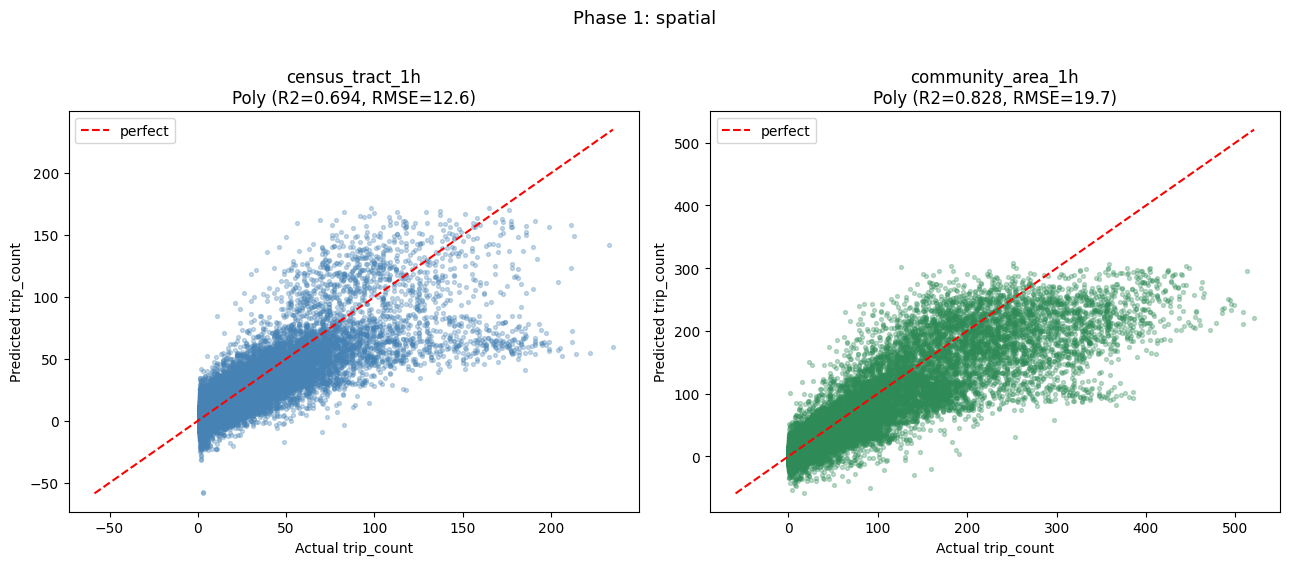

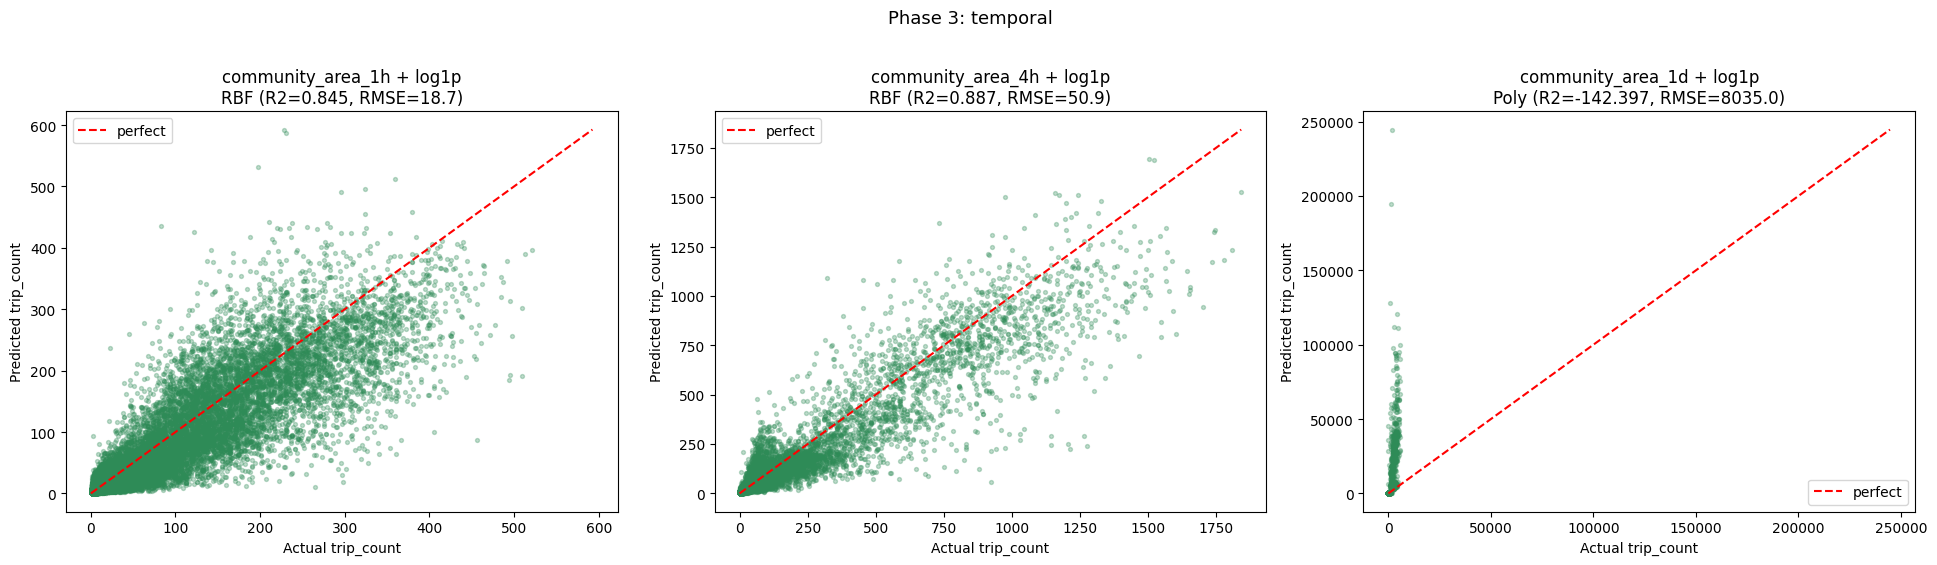

In [14]:
for title, d in [("Phase 1: spatial", phase1), ("Phase 3: temporal", phase3)]:
    n = len(d)
    fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5), squeeze=False)
    for ax, (k, res) in zip(axes[0], d.items()):
        yt, yp = res["y_test"], res["y_pred"]
        ax.scatter(yt, yp, s=8, alpha=0.3, color=SPATIAL_COLORS[res["spatial"]])
        lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        ax.plot(lims, lims, "r--", lw=1.5, label="perfect")
        ax.set_xlabel("Actual trip_count"); ax.set_ylabel("Predicted trip_count")
        ax.set_title(f"{res['tag']}\n{res['best_model']} (R2={res['test_r2']:.3f}, RMSE={res['test_rmse']:.1f})")
        ax.legend()
    fig.suptitle(title, y=1.02, fontsize=13)
    plt.tight_layout(); plt.show()


## 8.2) Metric comparison
Lower MAE/RMSE and higher R² are better.


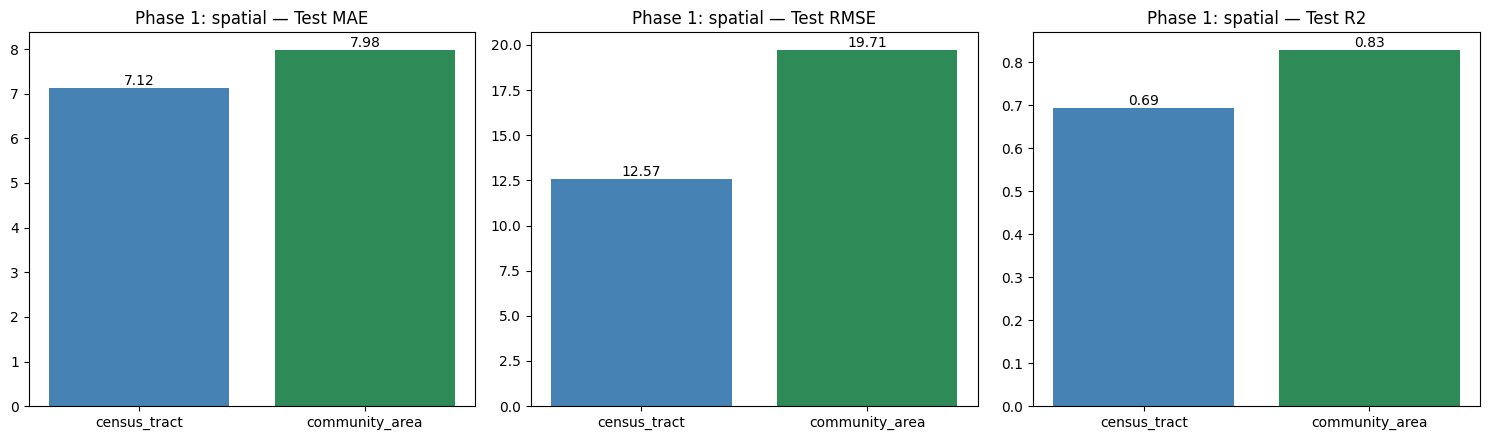

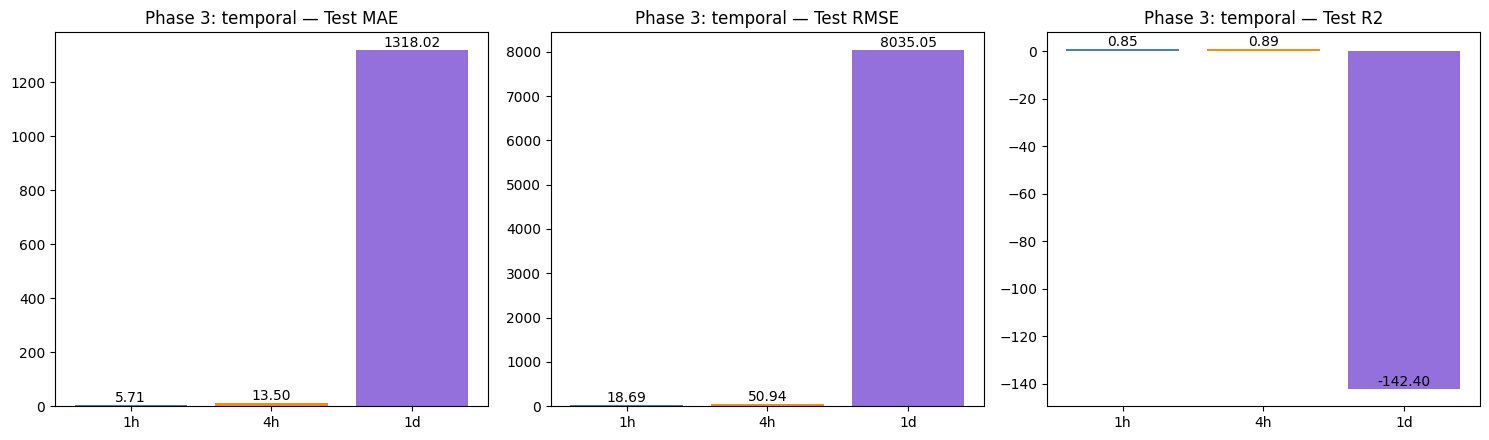

In [15]:
def metric_bars(results_dict, title, colors):
    metrics = ["test_mae", "test_rmse", "test_r2"]
    labels  = ["MAE", "RMSE", "R2"]
    names = list(results_dict.keys())
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, m, lab in zip(axes, metrics, labels):
        vals = [results_dict[n][m] for n in names]
        bars = ax.bar(names, vals, color=[colors.get(n, "steelblue") for n in names])
        ax.set_title(f"{title} — Test {lab}")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v:.2f}", ha="center", va="bottom")
    plt.tight_layout(); plt.show()

metric_bars(phase1, "Phase 1: spatial",
            {k: SPATIAL_COLORS[v["spatial"]] for k, v in phase1.items()})
metric_bars(phase3, "Phase 3: temporal", BIN_COLORS)


## 8.3) Model-family progression
Validation RMSE of the three kernel families shows how performance improves as the model becomes more complex (linear → RBF → polynomial).


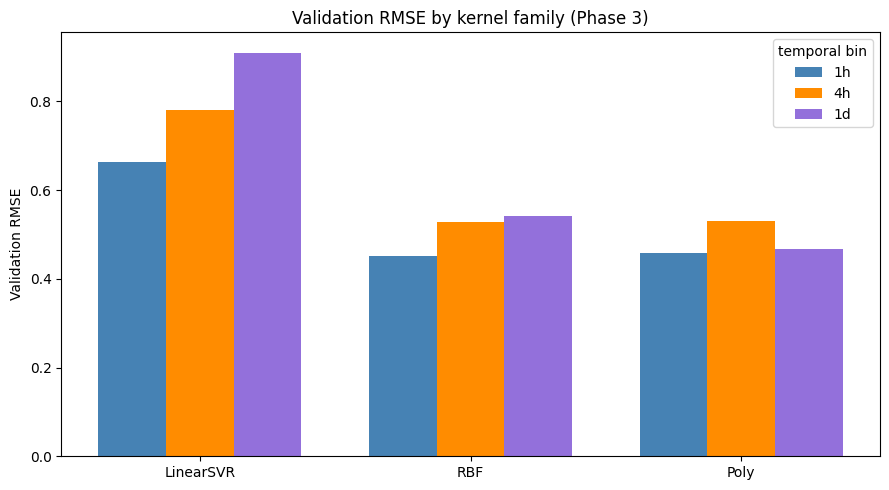

In [16]:
families = ["LinearSVR", "RBF", "Poly"]
x = np.arange(len(families))
width = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, b in enumerate(["1h", "4h", "1d"]):
    vals = [phase3[b]["all_val_rmse"].get(f, np.nan) for f in families]
    ax.bar(x + i * width, vals, width, label=b, color=BIN_COLORS[b])
ax.set_xticks(x + width); ax.set_xticklabels(families)
ax.set_ylabel("Validation RMSE"); ax.set_title("Validation RMSE by kernel family (Phase 3)")
ax.legend(title="temporal bin")
plt.tight_layout(); plt.show()


# 9) Shortfalls & improvement levers

**Model performance & shortfalls**
- *Right-skewed target*: `trip_count` has a long right tail, so the squared-error objective is dominated by a few high-demand baskets. The `log1p` transform (Phase 2) helps stabilise the variance but can reduce R² on the original scale because it under-predicts extreme peaks.
- *Sparse spatial units*: many census tracts contain only a handful of trips per basket, making per-unit predictions noisy — this is why the coarser **community area** layer generally fits better (more trips per unit, less noise).
- *Resolution trade-off*: finer temporal bins (1 h) give more detail but also more noise and sparser baskets; coarser bins (4 h, 1 d) aggregate demand and are easier to predict (higher R², lower MAPE) but lose intra-day structure.
- *SVR scaling limitation*: kernel SVR (RBF/Poly) scales ~O(n²), so grid search fits on a 20 k-row subsample and the final refit on 50 k rows — the full training set (300 k–600 k rows) is intractable for non-linear SVR.
- *No temporal dynamics*: the model receives no information about *recent* demand (no autoregressive lags), only calendar/weather/POI context.

**How performance varies with resolution**
- Increasing **spatial** resolution (community area → census tract) adds more, sparser units: MAE falls but R² drops and MAPE rises because small counts are harder to predict *relatively*.
- Increasing **temporal** resolution (1 d → 4 h → 1 h) adds noise: daily baskets are easiest to predict (highest R²), hourly the hardest.

**Improvement levers for a follow-up project**
- *Lagged / autoregressive features*: `trip_count` at t-1, t-24h and rolling means — the strongest short-term predictor.
- *Spatial features*: POI density, distance to CBD / nearest transit hub, neighbourhood embeddings.
- *Stronger learners*: gradient-boosted trees (LightGBM / XGBoost) handle non-linearities, large *n* and feature interactions far more efficiently than kernel SVR.
- *Spatial / grouped cross-validation*: group folds by spatial unit and time block so nearby/overlapping observations do not leak between folds.
- *Calibrated probabilistic forecasts*: predict demand distributions (quantiles) rather than point estimates.
